In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import mlflow
import mlflow.sklearn
import mlflow.xgboost

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # To keep notebook clean
print("Libraries for Advanced Modeling imported!")

Libraries for Advanced Modeling imported!


In [3]:
# Cell 2: Load FULL Data (Including all encoded categorical features)
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop('math score', axis=1)
y_train = train_df['math score']

X_test = test_df.drop('math score', axis=1)
y_test = test_df['math score']

print(f"Full Training Features Shape: {X_train.shape}")
print(f"Full Testing Features Shape: {X_test.shape}")
# Notice we have more columns now compared to the baseline!

Full Training Features Shape: (800, 14)
Full Testing Features Shape: (200, 14)


In [4]:
# Cell 3: Setup Models and Parameter Grids
# We keep grids small so it trains fast on your laptop, but proves the concept!

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
}

param_grids = {
    "RandomForest": {
        'n_estimators': [50, 100],
        'max_depth':[None, 5, 10],
        'min_samples_split': [2, 5]
    },
    "GradientBoosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    "XGBoost": {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

print("Models and Parameter grids defined!")

Models and Parameter grids defined!


In [5]:
mlflow.set_tracking_uri("sqlite:///../mlflow1.db")
mlflow.set_experiment("Student_Performance_Prediction")

best_models = {}
results =[]

for model_name in models.keys():
    print(f"\nTraining and Tuning {model_name}...")

    with mlflow.start_run(run_name=f"Tuned_{model_name}"):
        # 1. Hyperparameter Tuning using GridSearchCV (Cross-Validation = 5 folds)
        grid_search = GridSearchCV(
            estimator=models[model_name],
            param_grid=param_grids[model_name],
            cv=5,
            scoring='r2',
            n_jobs=-1 # Uses all your CPU cores for faster training!
        )
        grid_search.fit(X_train, y_train)

        # 2. Get the best model from the grid search
        best_model = grid_search.best_estimator_
        best_models[model_name] = best_model

        # 3. Predict on Test Set
        y_pred = best_model.predict(X_test)

        # 4. Calculate Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Best Params: {grid_search.best_params_}")
        print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

        # Save results for plotting later
        results.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

        # 5. Log to MLflow
        mlflow.log_param("model_type", model_name)
        # Log all best parameters found
        for param_name, param_value in grid_search.best_params_.items():
            mlflow.log_param(f"best_{param_name}", param_value)

        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)

        # Log the model
        if model_name == "XGBoost":
            mlflow.xgboost.log_model(best_model, f"{model_name}_model")
        else:
            mlflow.sklearn.log_model(best_model, f"{model_name}_model")

print("\n✅ All advanced models trained and logged to MLflow!")


Training and Tuning RandomForest...
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
RMSE: 5.94 | MAE: 4.62 | R2: 0.8549


2026/04/15 11:32:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 11:32:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training and Tuning GradientBoosting...
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
RMSE: 5.56 | MAE: 4.29 | R2: 0.8731


2026/04/15 11:32:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 11:32:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training and Tuning XGBoost...
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
RMSE: 5.74 | MAE: 4.39 | R2: 0.8645


2026/04/15 11:32:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✅ All advanced models trained and logged to MLflow!


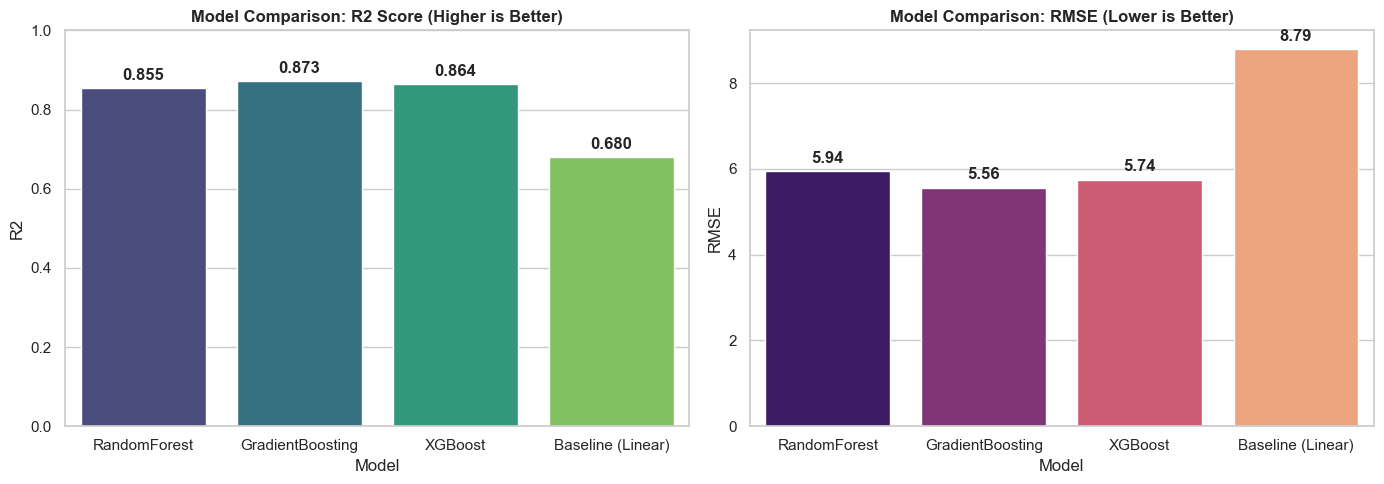

In [6]:
# Cell 5: Model Comparison Visualization

results_df = pd.DataFrame(results)
# Add Baseline scores manually for comparison
baseline_data = {'Model': 'Baseline (Linear)', 'RMSE': 8.79, 'MAE': 7.35, 'R2': 0.68}
results_df = pd.concat([results_df, pd.DataFrame([baseline_data])], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R2 Scores (Higher is better)
sns.barplot(ax=axes[0], x='Model', y='R2', data=results_df, palette='viridis')
axes[0].set_title('Model Comparison: R2 Score (Higher is Better)', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# Plot RMSE (Lower is better)
sns.barplot(ax=axes[1], x='Model', y='RMSE', data=results_df, palette='magma')
axes[1].set_title('Model Comparison: RMSE (Lower is Better)', fontweight='bold')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 0.2, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

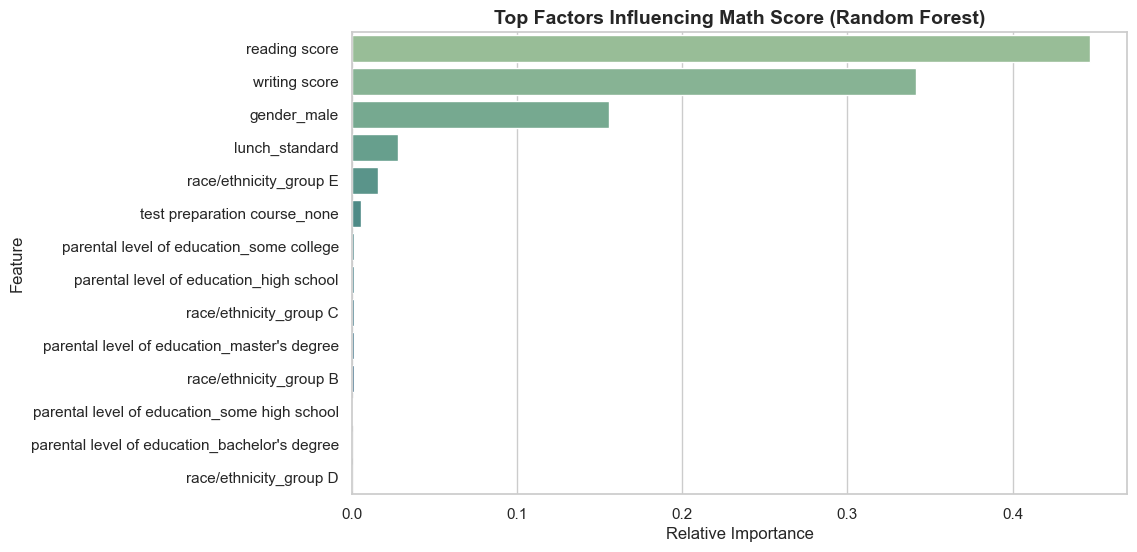

In [7]:
# Cell 6: Feature Importance Plot

# Let's assume XGBoost or RandomForest performed best. We'll use RandomForest for this plot.
best_rf = best_models['GradientBoosting']

# Get feature importances
importances = best_rf.feature_importances_
features = X_train.columns

# Create a DataFrame and sort it
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='crest')
plt.title('Top Factors Influencing Math Score (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()